Exercise 1 : Exploratory Data Analysis (Hard)


1. Understanding Business Case


2. Variable Description
* To know our variables before analyzing them.


3. Data Understanding
* After having understood the business case, import of the data  needed in CSV format. Then import of the necessary libraries. To finish, choice of the platform of the Jupyter Notebook for the analysis.

ie:
import numpy as np # linear algebra
import pandas as pd # data manipulation and analysis
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # data visualization
sns.set_style('whitegrid') # set style for visualization
import warnings # ignore warnings
warnings.filterwarnings('ignore')

Actions:
df = pd.read_csv('insurance.csv') : name of the database
df.head() : first 5 rows of the dataset.
df.sample(5) to get randomly select 5 rows or
df.tail() to get last 5 rows.
df.info() the index data type and columns, non-null values, and memory usage.
df.shape(): dimensions of the data frame
df.columns
df.describe()


4. Data Cleaning
df.isnull().sum() : missing values
df[df.duplicated(keep='first')]: duplicated values
drop_duplicates()


5. Data Visualization, with **seaborn** librairy

* Summary Statistics
* Frequency Distributions Table
* Charts ( Boxplot, Histogram, Barplot, Pie Chart)



Exercice 2: Analyse Exploratoire des Données du Titanic


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurer le style des graphiques pour une meilleure lisibilité
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6) # Taille par défaut des figures

print("--- Exercice 2: Analyse Exploratoire des Données du Titanic ---")

--- Exercice 2: Analyse Exploratoire des Données du Titanic ---


In [4]:

# --- 1. Chargement des Données ---
print("\n--- 1. Chargement des Données ---")
# Assurez-vous que le fichier 'Titanic-Dataset.csv' est dans le même répertoire
# ou est correctement chargé dans votre environnement Colab.
csv_path = '/content/Titanic-Dataset.csv'

try:
    df = pd.read_csv(csv_path)
    print(f"Jeu de données chargé depuis '{csv_path}'.")
except FileNotFoundError:
    print(f"Erreur: Le fichier '{csv_path}' n'a pas été trouvé.")
    print("Veuillez vous assurer que le fichier est correctement nommé et chargé dans votre environnement Colab.")
    exit() # Quitter si le fichier n'est pas trouvé


--- 1. Chargement des Données ---
Jeu de données chargé depuis '/content/Titanic-Dataset.csv'.


In [5]:
# --- 2. Inspection des Données ---
print("\n--- 2. Inspection des Données ---")
print("\nAperçu des 5 premières lignes du DataFrame:")
print(df.head())

print("\nInformations générales sur le DataFrame (types de données, non-nulls):")
df.info()

print("\nStatistiques descriptives des colonnes numériques:")
print(df.describe())

print("\nIdentification des valeurs manquantes:")
print(df.isnull().sum())


--- 2. Inspection des Données ---

Aperçu des 5 premières lignes du DataFrame:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  

**Résultats**

* Taille de l'ensemble de données contient 891 entrées (lignes) et 12 colonnes.

* Types de données : les colonnes ont différents types de données, notamment des entiers (int64), des nombres à virgule flottante (float64) et des objets (object), qui représentent souvent des chaînes de caractères.

* Valeurs manquantes :
La colonne Age a 177 valeurs manquantes.
La colonne Cabin a un grand nombre de valeurs manquantes (687).
La colonne Embarked a 2 valeurs manquantes.

Statistiques des colonnes numériques :la sortie de describe() fournit des statistiques clés pour les colonnes numériques comme PassengerId, Survived, Pclass, Age, SibSp, Parch et Fare. Cela inclut le nombre, la moyenne, l'écart type, le minimum, le maximum et les valeurs des quartiles. Par exemple, l'âge moyen est d'environ 29,7 ans et le tarif moyen est d'environ 32,2.

Colonnes catégorielles : Name, Sex, Ticket, Cabin et Embarked sont de type object et contiennent probablement des données catégorielles ou textuelles.

Cette inspection met en évidence le fait que nous avons des données manquantes dans Age, Cabin et Embarked, qui devront être traitées lors du nettoyage des données. Les statistiques descriptives nous donnent un premier aperçu de la distribution des caractéristiques numériques.



In [6]:
# --- 3. Nettoyage des Données ---
print("\n--- 3. Nettoyage des Données ---")

# Gérer les valeurs manquantes:
# 'Age': Imputer avec la médiane, car l'âge est une variable numérique et la médiane est robuste aux outliers.
print(f"Valeurs manquantes dans 'Age' avant imputation: {df['Age'].isnull().sum()}")
df['Age'].fillna(df['Age'].median(), inplace=True)
print(f"Valeurs manquantes dans 'Age' après imputation: {df['Age'].isnull().sum()}")

# 'Embarked': Imputer avec le mode (la valeur la plus fréquente), car c'est une variable catégorielle.
print(f"Valeurs manquantes dans 'Embarked' avant imputation: {df['Embarked'].isnull().sum()}")
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
print(f"Valeurs manquantes dans 'Embarked' après imputation: {df['Embarked'].isnull().sum()}")

# 'Cabin': Trop de valeurs manquantes (plus de 77%), la colonne pourrait ne pas être très utile.
# Pour cet EDA, nous allons la supprimer. Pour un modèle, on pourrait envisager une ingénierie de caractéristiques plus complexe.
print(f"Valeurs manquantes dans 'Cabin': {df['Cabin'].isnull().sum()} (Suppression de la colonne)")
df.drop('Cabin', axis=1, inplace=True)

print("\nValeurs manquantes après nettoyage:")
print(df.isnull().sum())

# Convertir les variables catégorielles en numérique (One-Hot Encoding):
# 'Sex': 'male'/'female' -> 0/1 ou colonnes binaires
# 'Embarked': 'S'/'C'/'Q' -> colonnes binaires
print("\nConversion des variables catégorielles ('Sex', 'Embarked') en numérique...")
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True) # drop_first pour éviter la multicolinéarité

# Renommer les colonnes créées pour plus de clarté
df.rename(columns={'Sex_male': 'IsMale', 'Embarked_Q': 'Embarked_Queenstown', 'Embarked_S': 'Embarked_Southampton'}, inplace=True)

print("\nAperçu du DataFrame après nettoyage et encodage:")
print(df.head())
df.info()



--- 3. Nettoyage des Données ---
Valeurs manquantes dans 'Age' avant imputation: 177
Valeurs manquantes dans 'Age' après imputation: 0
Valeurs manquantes dans 'Embarked' avant imputation: 2
Valeurs manquantes dans 'Embarked' après imputation: 0
Valeurs manquantes dans 'Cabin': 687 (Suppression de la colonne)

Valeurs manquantes après nettoyage:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Conversion des variables catégorielles ('Sex', 'Embarked') en numérique...

Aperçu du DataFrame après nettoyage et encodage:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Brau

/tmp/ipython-input-6-744086972.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipython-input-6-744086972.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t


Gestion des valeurs manquantes

La colonne Age qui contenait 177 valeurs manquantes a été imputée (remplie) avec la médiane des âges. Après cette opération, il n'y a plus de valeurs manquantes dans cette colonne.

La colonne Embarked qui contenait 2 valeurs manquantes a été imputée avec le mode (la valeur la plus fréquente) de cette colonne catégorielle. Après cette opération, il n'y a plus de valeurs manquantes dans cette colonne.

La colonne Cabin, qui avait un très grand nombre de valeurs manquantes (687), a été supprimée du DataFrame, car elle n'était probablement pas très utile pour l'analyse.

Vérification finale des valeurs manquantes : après ces opérations, la vérification df.isnull().sum() confirme qu'il n'y a plus aucune valeur manquante dans le DataFrame.

Conversion des variables catégorielles :
Les variables catégorielles Sex et Embarked ont été converties en format numérique en utilisant la technique de "One-Hot Encoding" (pd.get_dummies). Cela crée de nouvelles colonnes binaires pour chaque catégorie unique (sauf une par colonne d'origine pour éviter la multicolinéarité).

Les nouvelles colonnes créées ont été renommées pour plus de clarté (Sex_male devient IsMale, Embarked_Q devient Embarked_Queenstown, Embarked_S devient Embarked_Southampton).

Aperçu du DataFrame après nettoyage et encodage : la sortie montre les premières lignes du DataFrame après ces transformations. On peut voir les nouvelles colonnes booléennes (IsMale, Embarked_Queenstown, Embarked_Southampton) qui ont remplacé les colonnes Sex et Embarked d'origine, et la colonne Cabin a été supprimée. L'information df.info() confirme également les types de données et le nombre de colonnes final.

En résumé, cette étape a efficacement traité les valeurs manquantes et préparé les variables catégorielles pour l'analyse en les convertissant en un format numérique approprié.



--- 4. Analyse Exploratoire & 6. Visualisation ---

4.1. Analyse Univariée:


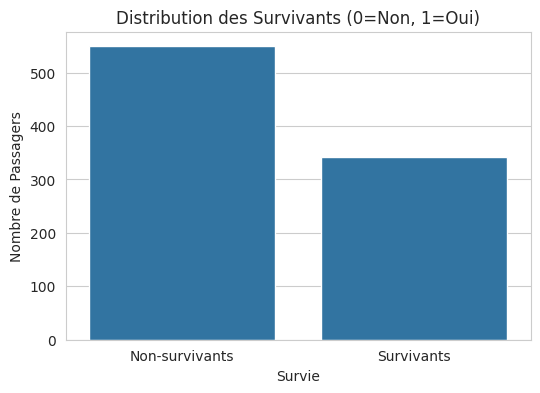

Insight: Environ un tiers des passagers ont survécu.


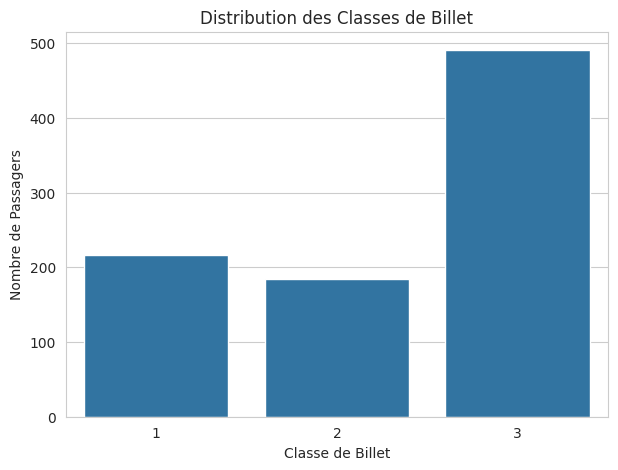

Insight: La 3ème classe était la plus nombreuse.


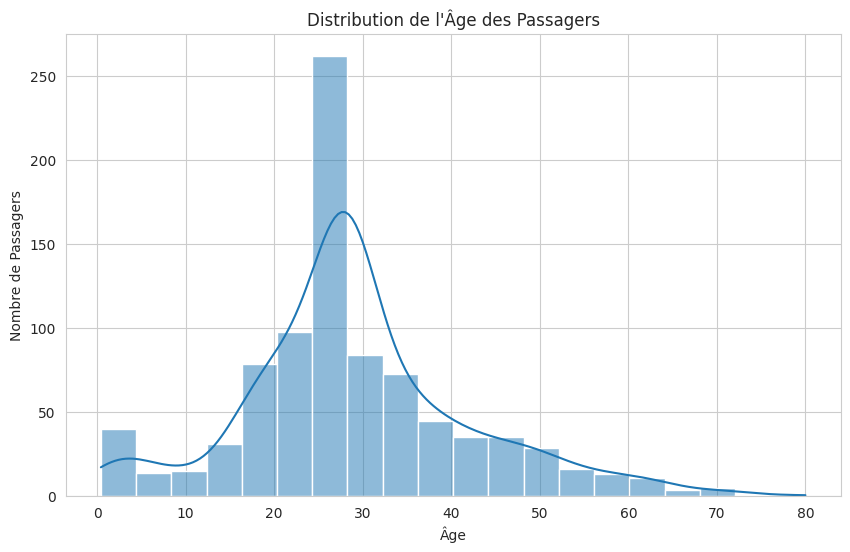

Insight: La majorité des passagers étaient de jeunes adultes.


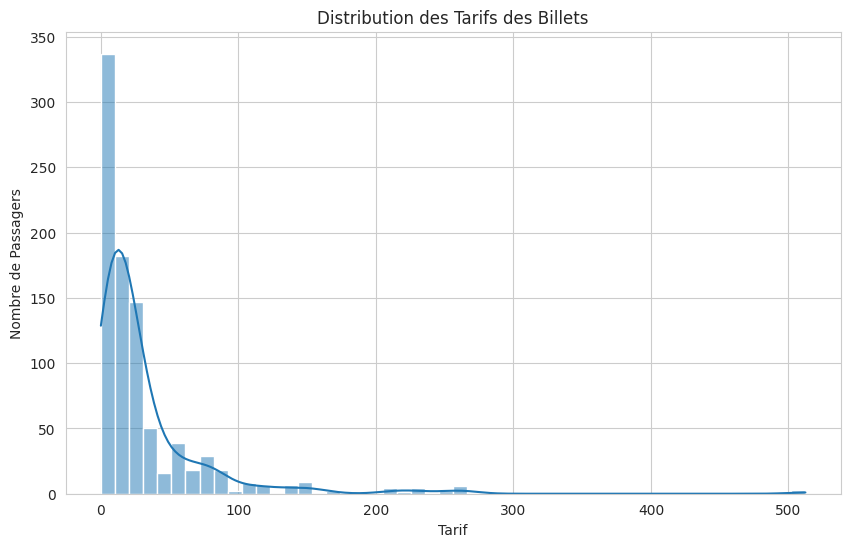

Insight: La plupart des tarifs étaient faibles, avec quelques tarifs très élevés.


In [7]:
# --- 4. Analyse Exploratoire & 6. Visualisation ---
print("\n--- 4. Analyse Exploratoire & 6. Visualisation ---")

# 4.1. Analyse Univariée
print("\n4.1. Analyse Univariée:")

# Distribution de 'Survived'
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df)
plt.title('Distribution des Survivants (0=Non, 1=Oui)')
plt.xlabel('Survie')
plt.ylabel('Nombre de Passagers')
plt.xticks(ticks=[0, 1], labels=['Non-survivants', 'Survivants'])
plt.show()
print("Insight: Environ un tiers des passagers ont survécu.")

# Distribution de 'Pclass'
plt.figure(figsize=(7, 5))
sns.countplot(x='Pclass', data=df)
plt.title('Distribution des Classes de Billet')
plt.xlabel('Classe de Billet')
plt.ylabel('Nombre de Passagers')
plt.show()
print("Insight: La 3ème classe était la plus nombreuse.")

# Distribution de 'Age'
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution de l\'Âge des Passagers')
plt.xlabel('Âge')
plt.ylabel('Nombre de Passagers')
plt.show()
print("Insight: La majorité des passagers étaient de jeunes adultes.")

# Distribution de 'Fare'
plt.figure(figsize=(10, 6))
sns.histplot(df['Fare'], bins=50, kde=True)
plt.title('Distribution des Tarifs des Billets')
plt.xlabel('Tarif')
plt.ylabel('Nombre de Passagers')
plt.show()
print("Insight: La plupart des tarifs étaient faibles, avec quelques tarifs très élevés.")



4.2. Analyse Bivariée (Relation avec la Survie):


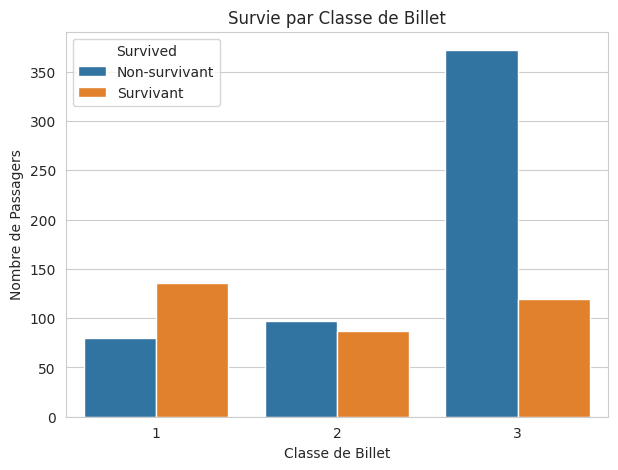

Insight: Les passagers de 1ère classe avaient une probabilité de survie beaucoup plus élevée.


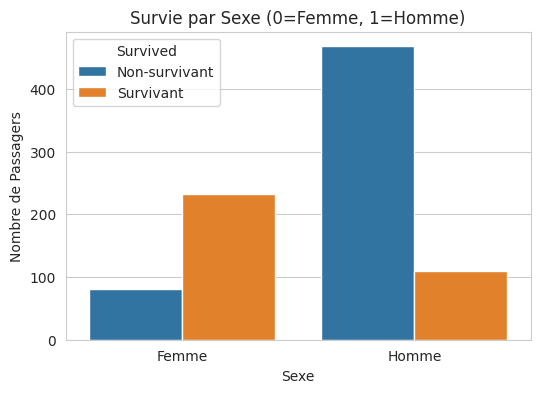

Insight: Les femmes étaient significativement plus susceptibles de survivre que les hommes.


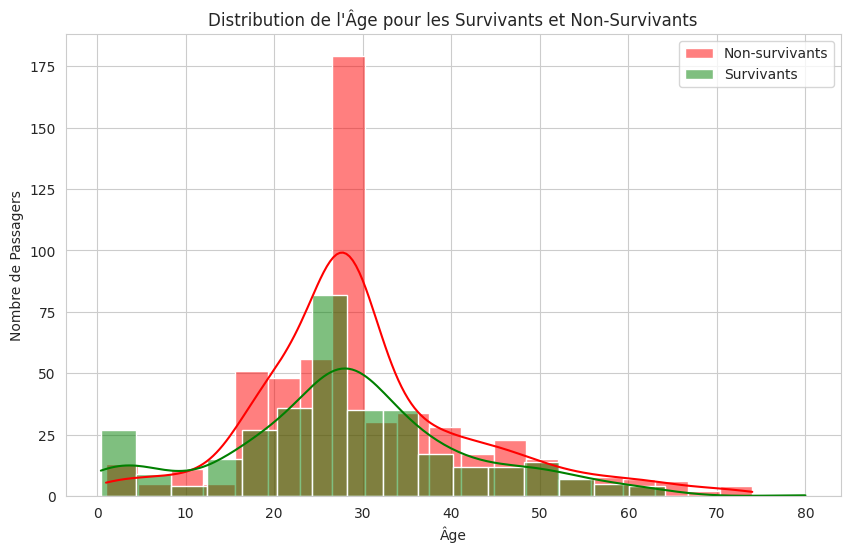

Insight: Les enfants (jeunes âges) semblent avoir eu une meilleure chance de survie.


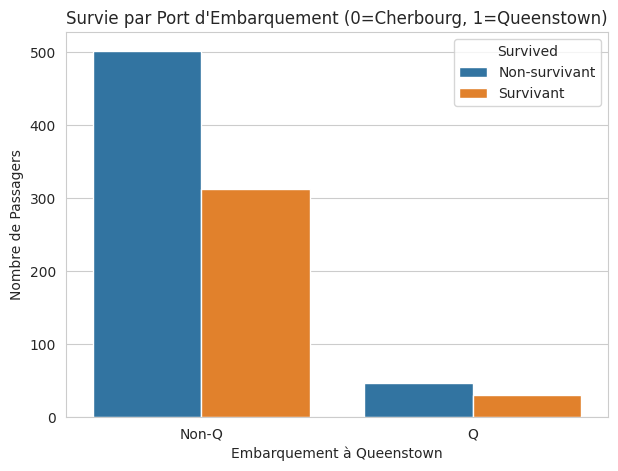

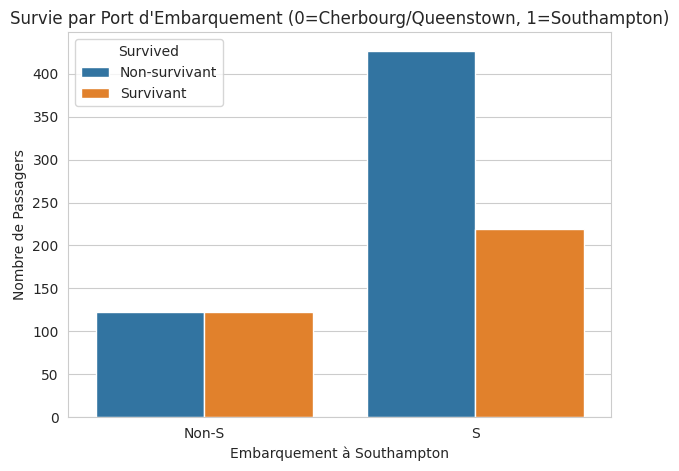

Insight: Le port d'embarquement semble avoir une influence, potentiellement liée à la classe des passagers.


In [8]:
# 4.2. Analyse Bivariée (Relation avec la Survie)
print("\n4.2. Analyse Bivariée (Relation avec la Survie):")

# Survie par 'Pclass'
plt.figure(figsize=(7, 5))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survie par Classe de Billet')
plt.xlabel('Classe de Billet')
plt.ylabel('Nombre de Passagers')
plt.legend(title='Survived', labels=['Non-survivant', 'Survivant'])
plt.show()
print("Insight: Les passagers de 1ère classe avaient une probabilité de survie beaucoup plus élevée.")

# Survie par 'Sex'
plt.figure(figsize=(6, 4))
sns.countplot(x='IsMale', hue='Survived', data=df)
plt.title('Survie par Sexe (0=Femme, 1=Homme)')
plt.xlabel('Sexe')
plt.ylabel('Nombre de Passagers')
plt.xticks(ticks=[0, 1], labels=['Femme', 'Homme'])
plt.legend(title='Survived', labels=['Non-survivant', 'Survivant'])
plt.show()
print("Insight: Les femmes étaient significativement plus susceptibles de survivre que les hommes.")

# Survie par 'Age' (distribution des âges pour survivants vs non-survivants)
plt.figure(figsize=(10, 6))
sns.histplot(df[df['Survived'] == 0]['Age'], bins=20, kde=True, color='red', label='Non-survivants')
sns.histplot(df[df['Survived'] == 1]['Age'], bins=20, kde=True, color='green', label='Survivants')
plt.title('Distribution de l\'Âge pour les Survivants et Non-Survivants')
plt.xlabel('Âge')
plt.ylabel('Nombre de Passagers')
plt.legend()
plt.show()
print("Insight: Les enfants (jeunes âges) semblent avoir eu une meilleure chance de survie.")

# Survie par 'Embarked'
plt.figure(figsize=(7, 5))
sns.countplot(x='Embarked_Queenstown', hue='Survived', data=df)
plt.title('Survie par Port d\'Embarquement (0=Cherbourg, 1=Queenstown)')
plt.xlabel('Embarquement à Queenstown')
plt.ylabel('Nombre de Passagers')
plt.xticks(ticks=[0, 1], labels=['Non-Q', 'Q'])
plt.legend(title='Survived', labels=['Non-survivant', 'Survivant'])
plt.show()

plt.figure(figsize=(7, 5))
sns.countplot(x='Embarked_Southampton', hue='Survived', data=df)
plt.title('Survie par Port d\'Embarquement (0=Cherbourg/Queenstown, 1=Southampton)')
plt.xlabel('Embarquement à Southampton')
plt.ylabel('Nombre de Passagers')
plt.xticks(ticks=[0, 1], labels=['Non-S', 'S'])
plt.legend(title='Survived', labels=['Non-survivant', 'Survivant'])
plt.show()
print("Insight: Le port d'embarquement semble avoir une influence, potentiellement liée à la classe des passagers.")



4.3. Analyse Multivariée:


<Figure size 900x600 with 0 Axes>

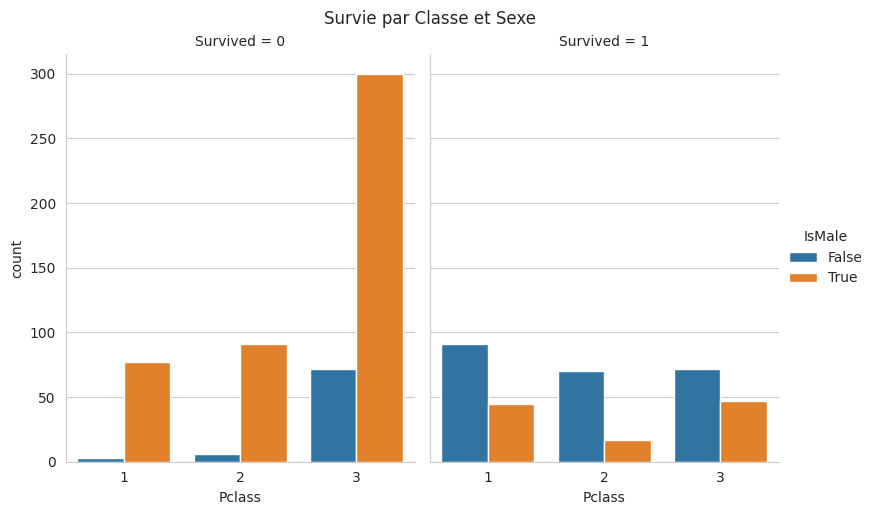

Insight: Les femmes de toutes les classes avaient un taux de survie plus élevé que les hommes.
Même les femmes de 3ème classe avaient une meilleure chance que les hommes de 1ère classe.

Matrice de corrélation des variables numériques:


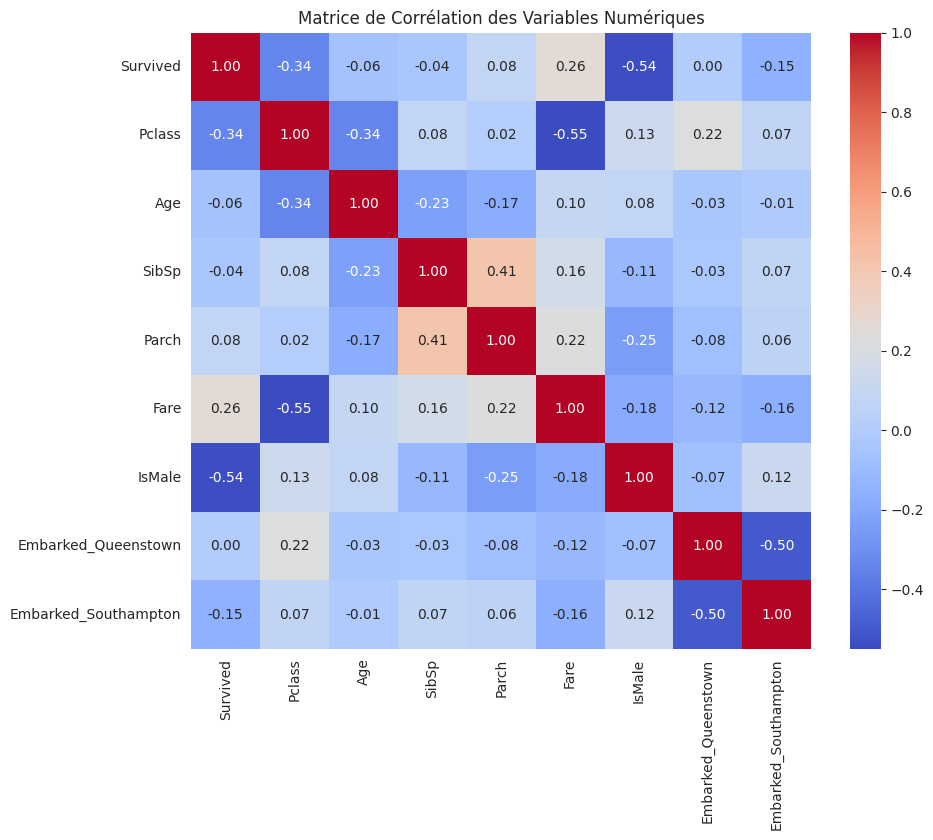

Insight: 'Survived' est fortement corrélé négativement avec 'Pclass' et 'IsMale' (sexe masculin),
ce qui confirme nos observations précédentes. 'Fare' est positivement corrélé avec 'Survived'.


In [9]:
# 4.3. Analyse Multivariée
print("\n4.3. Analyse Multivariée:")

# Survie par 'Pclass' et 'Sex'
plt.figure(figsize=(9, 6))
sns.catplot(x='Pclass', hue='IsMale', col='Survived', data=df, kind='count', height=5, aspect=0.8)
plt.suptitle('Survie par Classe et Sexe', y=1.02) # y pour ajuster le titre global
plt.show()
print("Insight: Les femmes de toutes les classes avaient un taux de survie plus élevé que les hommes.")
print("Même les femmes de 3ème classe avaient une meilleure chance que les hommes de 1ère classe.")

# Matrice de corrélation pour les variables numériques
print("\nMatrice de corrélation des variables numériques:")
# Sélectionner uniquement les colonnes numériques pertinentes pour la corrélation
numerical_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'IsMale', 'Embarked_Queenstown', 'Embarked_Southampton']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation des Variables Numériques')
plt.show()
print("Insight: 'Survived' est fortement corrélé négativement avec 'Pclass' et 'IsMale' (sexe masculin),")
print("ce qui confirme nos observations précédentes. 'Fare' est positivement corrélé avec 'Survived'.")


In [10]:
# --- 5. Génération d'Insights ---
print("\n--- 5. Génération d'Insights Clés ---")
print("Basé sur cette analyse exploratoire, voici quelques conclusions et patterns:")
print("1. Le taux de survie global était d'environ 38%.")
print("2. Le sexe a été le facteur le plus influent sur la survie: les femmes avaient un taux de survie bien plus élevé que les hommes.")
print("3. La classe de billet (Pclass) a également eu un impact majeur: les passagers de 1ère classe avaient une probabilité de survie significativement plus élevée que ceux des 2ème et 3ème classes.")
print("4. L'âge a joué un rôle, avec une tendance à une meilleure survie pour les enfants.")
print("5. Le tarif (Fare) est positivement corrélé avec la survie, ce qui est logique car des tarifs plus élevés sont associés aux classes supérieures.")
print("6. Le port d'embarquement semble avoir une corrélation indirecte avec la survie, probablement en raison de la composition socio-économique des passagers embarquant dans chaque port.")
print("\nCes insights confirment l'importance des facteurs socio-démographiques dans la survie au naufrage du Titanic.")

print("\nAnalyse Exploratoire des Données du Titanic terminée.")



--- 5. Génération d'Insights Clés ---
Basé sur cette analyse exploratoire, voici quelques conclusions et patterns:
1. Le taux de survie global était d'environ 38%.
2. Le sexe a été le facteur le plus influent sur la survie: les femmes avaient un taux de survie bien plus élevé que les hommes.
3. La classe de billet (Pclass) a également eu un impact majeur: les passagers de 1ère classe avaient une probabilité de survie significativement plus élevée que ceux des 2ème et 3ème classes.
4. L'âge a joué un rôle, avec une tendance à une meilleure survie pour les enfants.
5. Le tarif (Fare) est positivement corrélé avec la survie, ce qui est logique car des tarifs plus élevés sont associés aux classes supérieures.
6. Le port d'embarquement semble avoir une corrélation indirecte avec la survie, probablement en raison de la composition socio-économique des passagers embarquant dans chaque port.

Ces insights confirment l'importance des facteurs socio-démographiques dans la survie au naufrage du 

Exercise 3: Exploratory Data Analysis (EDA) on the Iris Dataset


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurer le style des graphiques pour une meilleure lisibilité
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6) # Taille par défaut des figures

print("--- Exercice 3: Analyse Exploratoire des Données du Iris ---")

--- Exercice 3: Analyse Exploratoire des Données du Iris ---


In [12]:
# --- 1. Chargement des Données ---
print("\n--- 1. Chargement des Données ---")
# Le jeu de données Iris est souvent inclus avec Seaborn, ce qui facilite le chargement.
try:
    df = sns.load_dataset('iris')
    print("Jeu de données Iris chargé avec succès.")
except Exception as e:
    print(f"Erreur lors du chargement du jeu de données Iris: {e}")
    print("Veuillez vous assurer que seaborn est correctement installé.")
    exit()



--- 1. Chargement des Données ---
Jeu de données Iris chargé avec succès.


In [13]:
# --- 2. Inspection des Données ---
print("\n--- 2. Inspection des Données ---")
print("\nAperçu des 5 premières lignes du DataFrame:")
print(df.head())

print("\nInformations générales sur le DataFrame (types de données, non-nulls):")
df.info()

print("\nStatistiques descriptives des colonnes numériques:")
print(df.describe())

print("\nIdentification des valeurs manquantes:")
print(df.isnull().sum())
if df.isnull().sum().sum() == 0:
    print("Aucune valeur manquante trouvée dans le jeu de données.")
else:
    print("Des valeurs manquantes ont été trouvées. Un nettoyage pourrait être nécessaire (non requis pour Iris).")


print("\nEspèces uniques présentes dans le jeu de données et leur distribution:")
print(df['species'].value_counts())
print("Insight: Le jeu de données est parfaitement équilibré avec 50 échantillons pour chaque espèce.")



--- 2. Inspection des Données ---

Aperçu des 5 premières lignes du DataFrame:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Informations générales sur le DataFrame (types de données, non-nulls):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Statis


--- 3. Visualisation des Données & 4. Analyse Exploratoire ---

4.1. Analyse Univariée: Histograms des caractéristiques


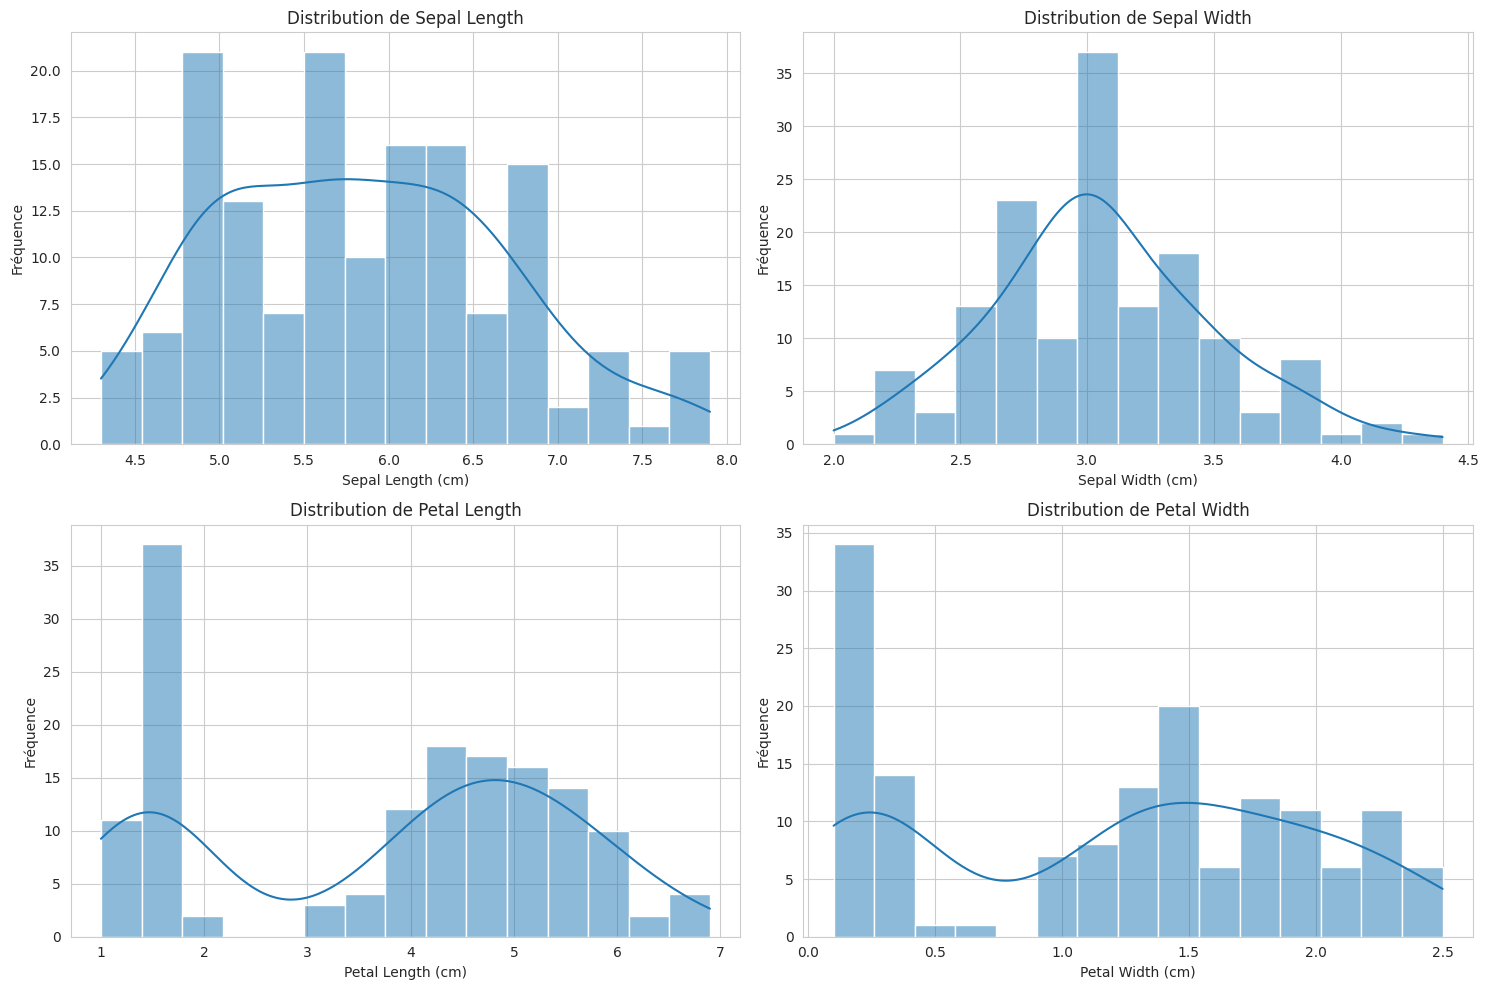

Insight: Les longueurs des pétales et des sépales ont des distributions multi-modales, suggérant des différences entre les espèces.
La largeur des sépales semble avoir une distribution plus normale.

Analyse Univariée par Espèce: Histograms des caractéristiques par espèce


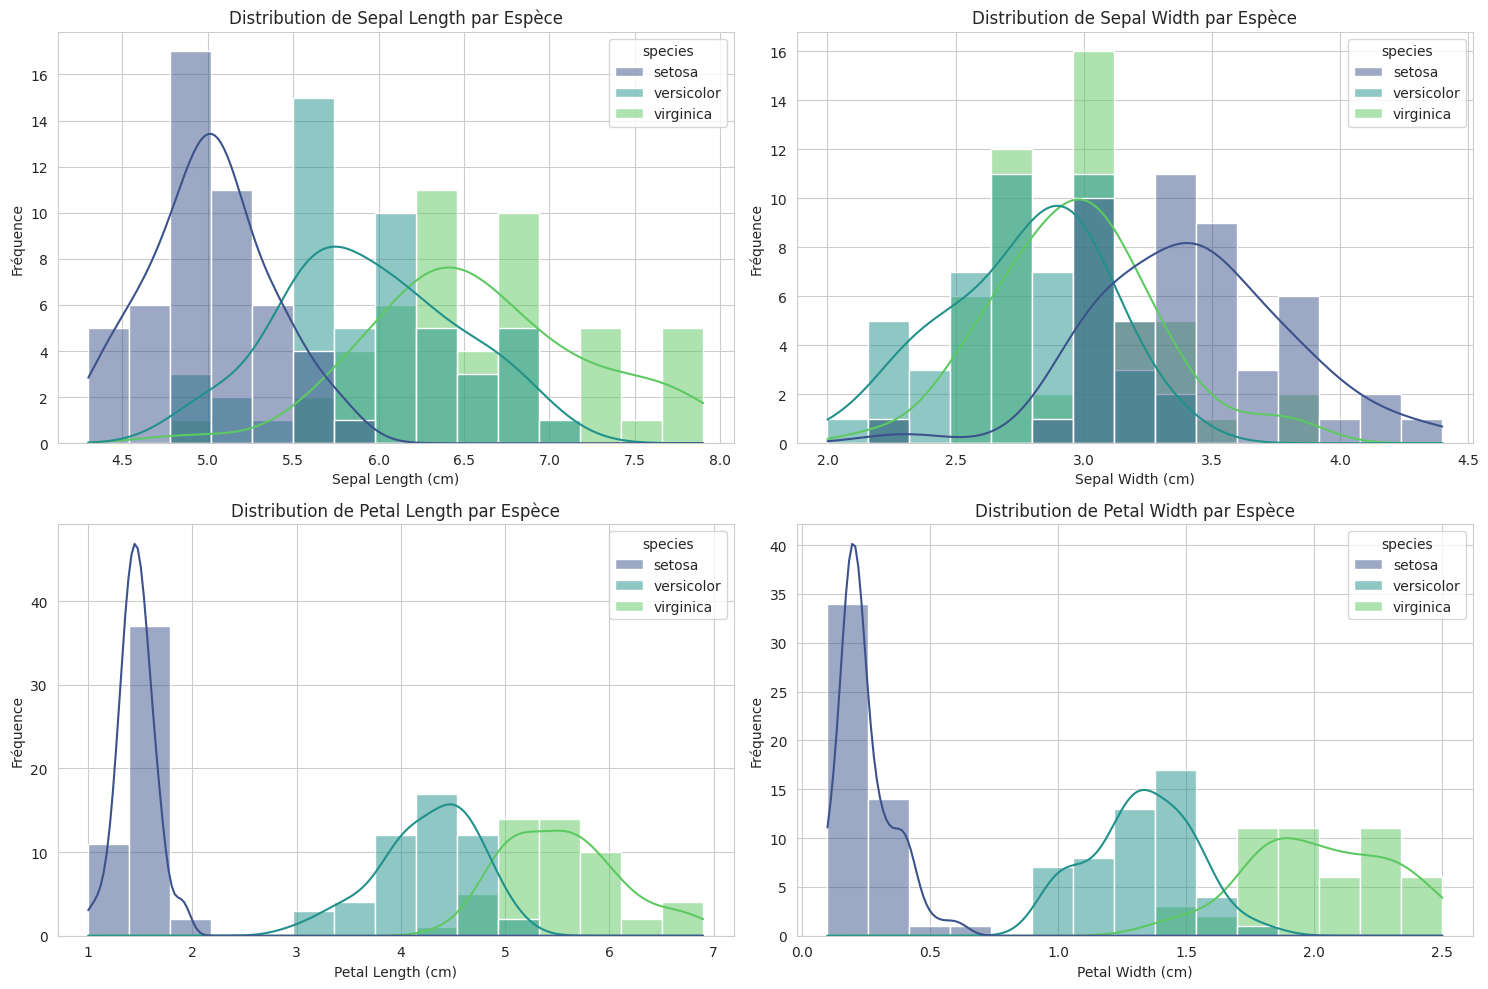

Insight: Setosa est clairement distincte avec des pétales plus courts et plus étroits, et des sépales plus courts.
Versicolor et Virginica se chevauchent davantage, mais Virginica a généralement des mesures plus grandes.


In [14]:
# --- 3. Visualisation des Données & 4. Analyse Exploratoire ---
print("\n--- 3. Visualisation des Données & 4. Analyse Exploratoire ---")

# 4.1. Analyse Univariée: Distribution de chaque caractéristique
print("\n4.1. Analyse Univariée: Histograms des caractéristiques")
numerical_features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[feature], kde=True, bins=15)
    plt.title(f'Distribution de {feature.replace("_", " ").title()}')
    plt.xlabel(f'{feature.replace("_", " ").title()} (cm)')
    plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()
print("Insight: Les longueurs des pétales et des sépales ont des distributions multi-modales, suggérant des différences entre les espèces.")
print("La largeur des sépales semble avoir une distribution plus normale.")


# Analyse Univariée par espèce (Histograms avec hue)
print("\nAnalyse Univariée par Espèce: Histograms des caractéristiques par espèce")
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1)
    sns.histplot(data=df, x=feature, hue='species', kde=True, bins=15, palette='viridis')
    plt.title(f'Distribution de {feature.replace("_", " ").title()} par Espèce')
    plt.xlabel(f'{feature.replace("_", " ").title()} (cm)')
    plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()
print("Insight: Setosa est clairement distincte avec des pétales plus courts et plus étroits, et des sépales plus courts.")
print("Versicolor et Virginica se chevauchent davantage, mais Virginica a généralement des mesures plus grandes.")



4.2. Analyse Bivariée: Scatter Plots des paires de caractéristiques


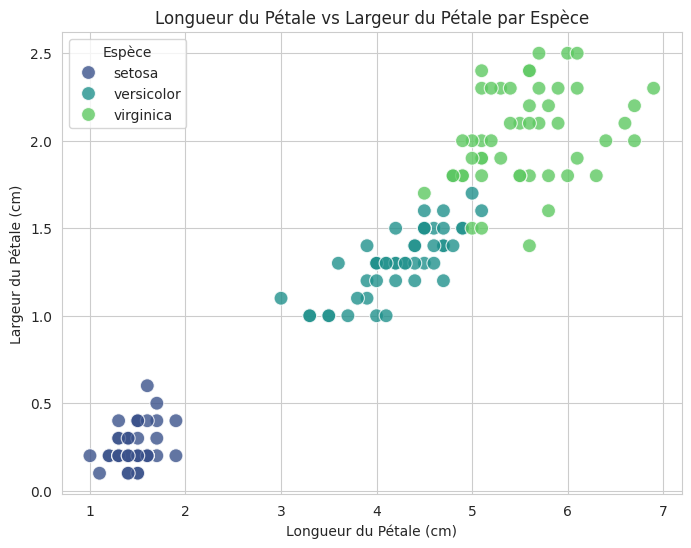

Insight: Les longueurs et largeurs des pétales sont très discriminantes pour les espèces.
Setosa forme un cluster distinct, tandis que Versicolor et Virginica sont séparables mais avec un certain chevauchement.


In [15]:
# 4.2. Analyse Bivariée: Relations entre paires de caractéristiques (Scatter Plots)
print("\n4.2. Analyse Bivariée: Scatter Plots des paires de caractéristiques")

# Exemple de scatter plot pour Petal Length vs Petal Width, coloré par espèce
plt.figure(figsize=(8, 6))
sns.scatterplot(x='petal_length', y='petal_width', hue='species', data=df, s=100, alpha=0.8, palette='viridis')
plt.title('Longueur du Pétale vs Largeur du Pétale par Espèce')
plt.xlabel('Longueur du Pétale (cm)')
plt.ylabel('Largeur du Pétale (cm)')
plt.legend(title='Espèce')
plt.show()
print("Insight: Les longueurs et largeurs des pétales sont très discriminantes pour les espèces.")
print("Setosa forme un cluster distinct, tandis que Versicolor et Virginica sont séparables mais avec un certain chevauchement.")




4.3. Analyse Multivariée: Pair Plot (relations complexes)


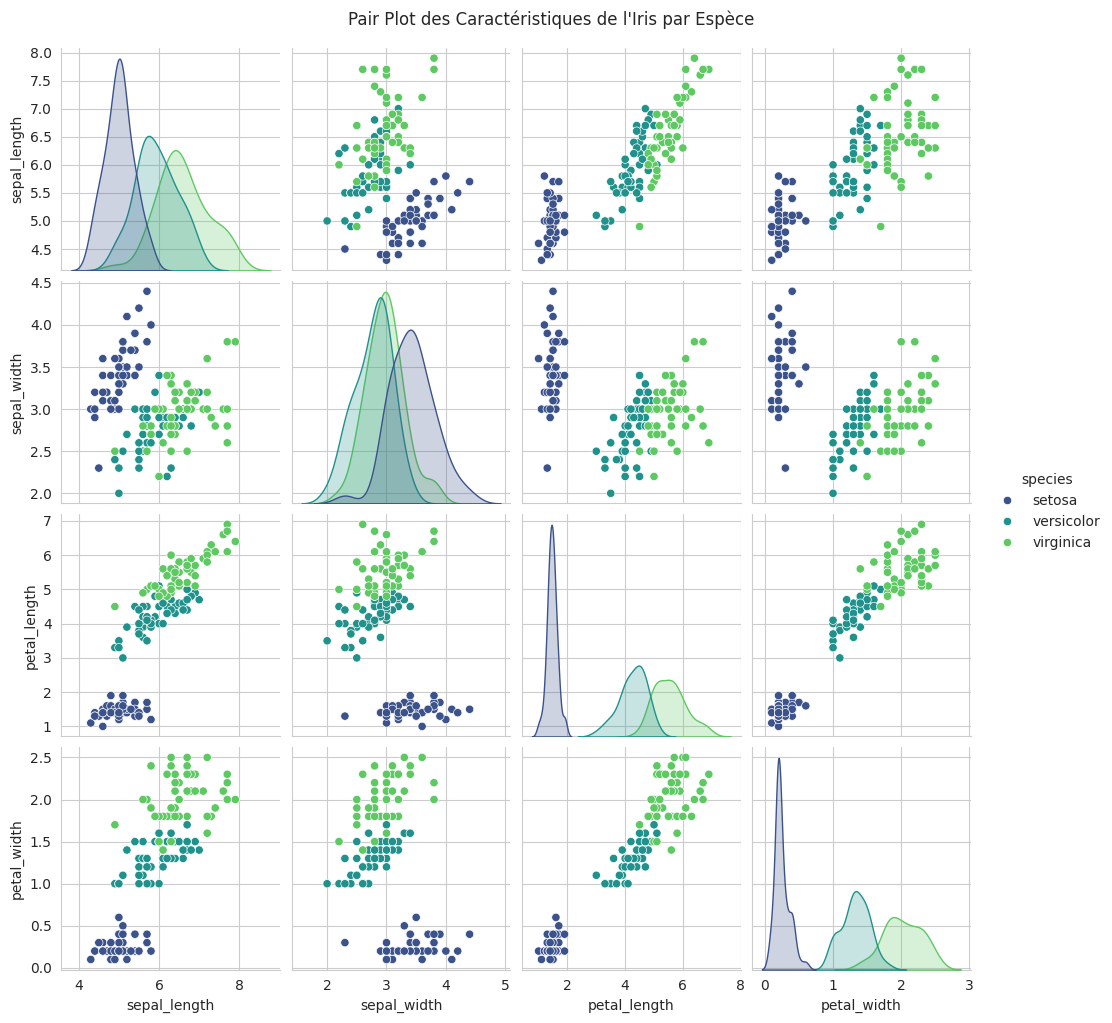

Insight: Le Pair Plot confirme visuellement que 'petal_length' et 'petal_width' sont les caractéristiques les plus discriminantes.
Setosa est facilement séparable des deux autres espèces sur presque tous les graphiques.


In [16]:
# 4.3. Analyse Multivariée: Pair Plot pour toutes les caractéristiques
print("\n4.3. Analyse Multivariée: Pair Plot (relations complexes)")
# Pair plot est excellent pour visualiser toutes les relations bivariées et les distributions univariées
sns.pairplot(df, hue='species', palette='viridis', diag_kind='kde')
plt.suptitle('Pair Plot des Caractéristiques de l\'Iris par Espèce', y=1.02) # Ajuste le titre global
plt.show()
print("Insight: Le Pair Plot confirme visuellement que 'petal_length' et 'petal_width' sont les caractéristiques les plus discriminantes.")
print("Setosa est facilement séparable des deux autres espèces sur presque tous les graphiques.")




In [17]:
# --- 5. Génération d'Insights ---
print("\n--- 5. Génération d'Insights Clés ---")
print("Basé sur cette analyse exploratoire, voici les caractéristiques clés qui différencient chaque espèce:")

print("1.  **Iris Setosa:**")
print("    * Se distingue très clairement des autres espèces par ses **pétales beaucoup plus courts et plus étroits**.")
print("    * Elle a également des sépales généralement plus courts et plus larges par rapport à sa longueur.")
print("    * Elle forme un cluster distinct et est facilement séparable des autres sur la plupart des graphiques de dispersion.")

print("2.  **Iris Versicolor:**")
print("    * Ses mesures de pétales (longueur et largeur) sont intermédiaires entre Setosa et Virginica.")
print("    * Elle chevauche légèrement Virginica, mais ses pétales sont généralement plus courts et plus étroits que ceux de Virginica.")

print("3.  **Iris Virginica:**")
print("    * Possède les **pétales les plus longs et les plus larges** en moyenne.")
print("    * Ses sépales sont également les plus longs en moyenne.")
print("    * Elle se distingue de Versicolor par des mesures globalement plus grandes, bien qu'il y ait un certain chevauchement.")

print("\nMotifs et observations intéressantes:")
print("    * Les **mesures des pétales (longueur et largeur)** sont les caractéristiques les plus discriminantes pour séparer les espèces.")
print("    * La **longueur des sépales** est également utile, mais la largeur des sépales l'est moins pour la séparation des classes.")
print("    * Le jeu de données est parfaitement équilibré, ce qui est idéal pour l'entraînement de modèles de classification.")




--- 5. Génération d'Insights Clés ---
Basé sur cette analyse exploratoire, voici les caractéristiques clés qui différencient chaque espèce:
1.  **Iris Setosa:**
    * Se distingue très clairement des autres espèces par ses **pétales beaucoup plus courts et plus étroits**.
    * Elle a également des sépales généralement plus courts et plus larges par rapport à sa longueur.
    * Elle forme un cluster distinct et est facilement séparable des autres sur la plupart des graphiques de dispersion.
2.  **Iris Versicolor:**
    * Ses mesures de pétales (longueur et largeur) sont intermédiaires entre Setosa et Virginica.
    * Elle chevauche légèrement Virginica, mais ses pétales sont généralement plus courts et plus étroits que ceux de Virginica.
3.  **Iris Virginica:**
    * Possède les **pétales les plus longs et les plus larges** en moyenne.
    * Ses sépales sont également les plus longs en moyenne.
    * Elle se distingue de Versicolor par des mesures globalement plus grandes, bien qu'il 


--- 6. Visualisation Avancée ---

Boxplots: Comparaison des distributions de caractéristiques par espèce


/tmp/ipython-input-18-1100840299.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=df, palette='viridis')
/tmp/ipython-input-18-1100840299.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=df, palette='viridis')
/tmp/ipython-input-18-1100840299.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=df, palette='viridis')
/tmp/ipython-input-18-1100840299.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v

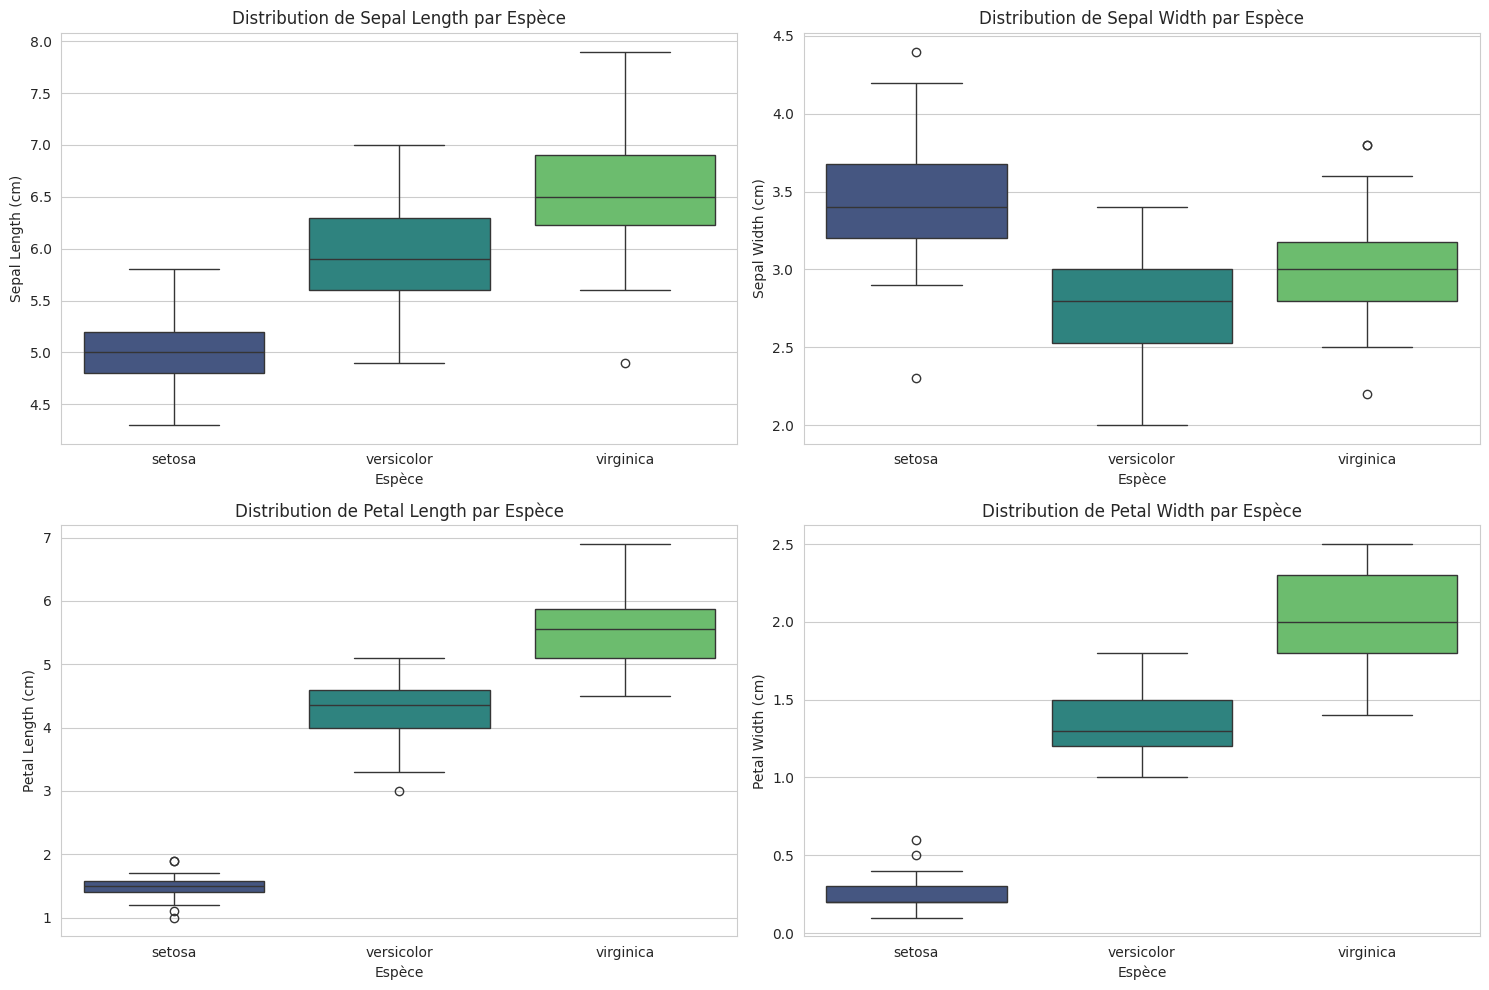

Insight: Les boxplots confirment visuellement la séparation des espèces par les mesures des pétales,
avec Setosa ayant des valeurs très différentes et peu de chevauchement avec les autres.

Heatmap: Corrélation entre toutes les caractéristiques


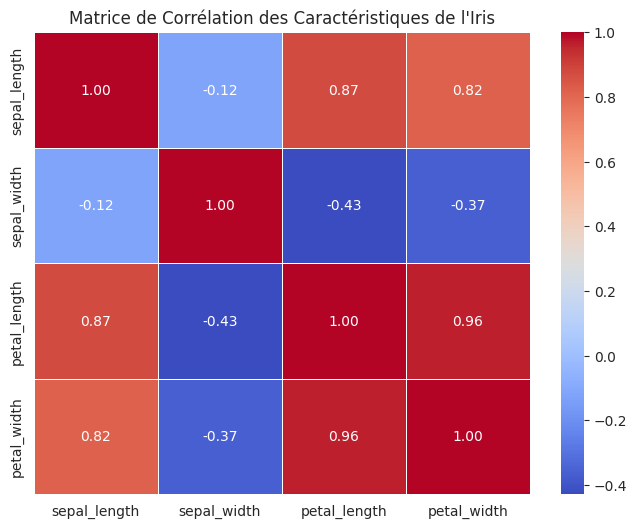

Insight: Les longueurs et largeurs des pétales sont fortement corrélées entre elles (positivement).
La longueur des sépales est également positivement corrélée avec la longueur et la largeur des pétales.
La largeur des sépales a une corrélation plus faible avec les autres caractéristiques.

Analyse Exploratoire des Données du Iris terminée.


In [18]:
# --- 6. Visualisation Avancée ---
print("\n--- 6. Visualisation Avancée ---")

# Boxplots pour comparer la distribution des caractéristiques à travers les espèces
print("\nBoxplots: Comparaison des distributions de caractéristiques par espèce")
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='species', y=feature, data=df, palette='viridis')
    plt.title(f'Distribution de {feature.replace("_", " ").title()} par Espèce')
    plt.xlabel('Espèce')
    plt.ylabel(f'{feature.replace("_", " ").title()} (cm)')
plt.tight_layout()
plt.show()
print("Insight: Les boxplots confirment visuellement la séparation des espèces par les mesures des pétales,")
print("avec Setosa ayant des valeurs très différentes et peu de chevauchement avec les autres.")


# Heatmap pour visualiser la corrélation entre toutes les caractéristiques
print("\nHeatmap: Corrélation entre toutes les caractéristiques")
# Exclure la colonne 'species' pour la corrélation car elle est catégorielle
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matrice de Corrélation des Caractéristiques de l\'Iris')
plt.show()
print("Insight: Les longueurs et largeurs des pétales sont fortement corrélées entre elles (positivement).")
print("La longueur des sépales est également positivement corrélée avec la longueur et la largeur des pétales.")
print("La largeur des sépales a une corrélation plus faible avec les autres caractéristiques.")


print("\nAnalyse Exploratoire des Données du Iris terminée.")
